# 2. Named entities and co-mention networks

Who gets talked about, and who gets talked about *together*?

Co-mention networks are a workhorse of media analysis: run named-entity
recognition over the text, connect entities that appear close to each other, and
the resulting graph shows the structure of a discourse — which people cluster
with which organisations, which topics bridge otherwise separate conversations.

This notebook runs spaCy over podcast turns and builds that graph. The
methodological work is in choosing the **window** — what counts as "together" —
and in not being fooled by frequency.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
# Report the location relative to here, so the printed output does not embed
# whoever's home directory this happened to be built in.
print("sporc", sporc.__version__, "from",
      os.path.relpath(os.path.dirname(sporc.__file__)))


sporc 1.1.0 from ../../sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md. Kept
# relative so nothing machine-specific leaks into the logged path.
SUBSET = "../../subsets/tutorial"
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from ../../subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache ../../subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.21s  (514 podcasts, 4,072 episodes)


SPORCDataset(parquet, 514 podcasts, 4072 episodes)


In [3]:
import spacy

# en_core_web_sm is fast and adequate for PERSON/ORG/GPE on clean-ish text.
# For publication work, en_core_web_trf is materially better on transcripts.
try:
    # NER needs only tok2vec + ner. The parser is the expensive pipe and nothing
    # here uses a dependency tree, so dropping the rest is ~3x faster.
    nlp = spacy.load(
        "en_core_web_sm",
        disable=["parser", "tagger", "attribute_ruler", "lemmatizer"],
    )
except OSError:
    raise SystemExit("Missing model. Run: python -m spacy download en_core_web_sm")
except ImportError as e:
    # spacy.load() imports every registered spacy_factories entry point, so one
    # broken plugin breaks every model -- including this one, which does not use
    # transformers at all. spacy-transformers pins transformers<4.53, so any
    # env with transformers>=5 hits this.
    if "BatchEncoding" in str(e) or "transformers" in str(e):
        import transformers
        raise SystemExit(
            "spaCy cannot load: the installed spacy-transformers is incompatible "
            f"with transformers {transformers.__version__}.\n"
            "spacy-transformers pins transformers<4.53.3 (true of every release, "
            "incl. 1.4.0), and it registers a 'transformer' factory that "
            "spacy.load() imports for ANY model.\n\n"
            "This notebook only needs en_core_web_sm, which does not use "
            "transformers. Either:\n"
            "    pip uninstall spacy-transformers      # simplest; nothing here needs it\n"
            "    pip install 'transformers<4.53'       # if you need spacy-transformers\n"
        ) from e
    raise

print("spaCy", spacy.__version__, "| pipes:", nlp.pipe_names)


spaCy 3.8.7 | pipes: ['tok2vec', 'ner']


## 2.1 Getting text out of the corpus

Two sources, and they are not equivalent:

* `episode.transcript` — the whole episode as one string. Available for **every**
  episode.
* `episode.turns` — the diarized turns. Available for **~65%** of episodes
  (notebook 01), but carries speaker and timing.

For co-mention we want locality: two names in the same *turn* are plausibly
related; two names 40 minutes apart in a transcript are not. So we use turns, and
accept the coverage cost.


In [4]:
import random

# The whole subset is 2,421 diarized episodes / ~13.9M words -- ~10 minutes of
# NER even with the trimmed pipeline. A sample keeps this notebook interactive
# and still leaves tens of thousands of turns to build a graph from. Raise
# N_EPISODES (or set it to None for all of them) if you have time to spend.
N_EPISODES = 300

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data]
print(f"episodes with turn data: {len(eps):,}")

if N_EPISODES and len(eps) > N_EPISODES:
    # Sort before sampling: iterate_episodes() order follows partition layout,
    # so seeding alone would not survive a resubset.
    eps.sort(key=lambda e: (e.podcast_title, e.title))
    eps = random.Random(0).sample(eps, N_EPISODES)
    print(f"sampled                : {len(eps):,}")

docs = []          # (text, episode_id, podcast_title)
for e in eps:
    for t in e.turns:
        txt = t.text.strip()
        if len(txt.split()) >= 8:        # very short turns carry no co-mention
            docs.append((txt, e.title, e.podcast_title))

print(f"turns to process       : {len(docs):,}")
print(f"approx words           : {sum(len(d[0].split()) for d in docs):,}")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


episodes with turn data: 4,072
sampled                : 300


turns to process       : 22,388


approx words           : 1,541,110


In [5]:
from collections import Counter, defaultdict
import itertools

KEEP = {"PERSON", "ORG", "GPE", "NORP", "EVENT"}

def normalize(text):
    """Fold trivial variants together. Real work needs entity linking."""
    t = " ".join(text.split())
    t = t.strip(".,!?;:'\"")
    for prefix in ("the ", "The "):
        if t.startswith(prefix):
            t = t[len(prefix):]
    return t

ent_counts = Counter()
ent_types = {}
pairs = Counter()

# nlp.pipe batches many short docs through the model at once, which matters far
# more than batch_size here. n_process forks workers; keep it modest on a shared
# box. This prints nothing until it finishes -- expect a minute or two.
texts = [d[0] for d in docs]
for doc in nlp.pipe(texts, batch_size=128, n_process=4):
    ents = []
    for ent in doc.ents:
        if ent.label_ not in KEEP:
            continue
        name = normalize(ent.text)
        if len(name) < 3 or name.isdigit():
            continue
        ents.append(name)
        ent_counts[name] += 1
        ent_types[name] = ent.label_
    # Co-mention = same turn. Dedupe within the turn so one repeated name
    # doesn't inflate its own edges.
    for a, b in itertools.combinations(sorted(set(ents)), 2):
        pairs[(a, b)] += 1

print(f"distinct entities : {len(ent_counts):,}")
print(f"co-mention pairs  : {len(pairs):,}")


distinct entities : 8,955
co-mention pairs  : 104,340


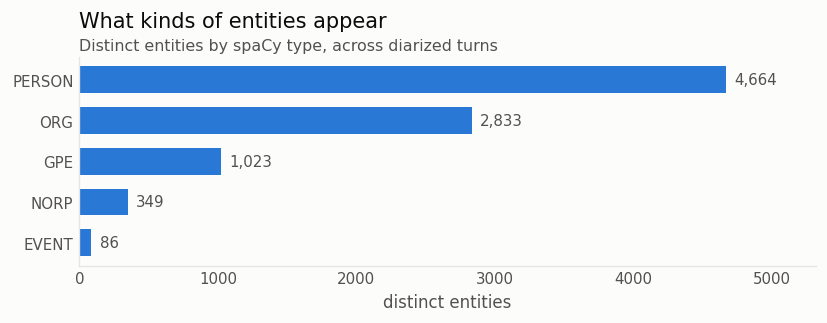

In [6]:
import matplotlib.pyplot as plt
from _viz import fold_other

by_type = Counter(ent_types[e] for e in ent_counts)
rows = sorted(by_type.items(), key=lambda kv: -kv[1])
labels = [r[0] for r in rows][::-1]
values = [r[1] for r in rows][::-1]

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(labels, values, color=PALETTE[0], height=0.66)
ax.grid(False, axis="y")
for y, v in enumerate(values):
    ax.annotate(f"{v:,}", (v, y), xytext=(5, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK_SECONDARY)
ax.set_xlim(0, max(values) * 1.14)
finish(ax, title="What kinds of entities appear",
       subtitle="Distinct entities by spaCy type, across diarized turns",
       xlabel="distinct entities")
plt.show()


## 2.2 The most-mentioned entities

Look at this list critically. ASR transcripts produce entity noise: mis-heard
names, brand names from ads, the podcast's own title. Frequency alone is rarely
the interesting signal.


In [7]:
top = ent_counts.most_common(20)
for name, n in top:
    print(f"  {n:5d}  {ent_types[name]:7s}  {name}")


    341  PERSON   Jesus
    199  GPE      Ozena
    145  PERSON   Paul
    133  ORG      Instagram
    133  ORG      Trump
    114  PERSON   COVID-19
    113  PERSON   COVID
    105  NORP     Christian
    105  PERSON   Peter
    105  PERSON   Chris
    102  PERSON   Twitter
    101  PERSON   David
     93  ORG      Genesis
     91  ORG      YouTube
     89  NORP     American
     86  GPE      America
     85  ORG      New York
     85  PERSON   Chavez
     78  ORG      NBA
     76  PERSON   Dan


## 2.3 The co-mention graph

Nodes are entities, edges are "mentioned in the same turn". Two thresholds
matter, and both are judgement calls you should state:

* **min mentions** — drop entities too rare to place reliably.
* **min co-mentions** — drop pairs that co-occurred once, which is usually
  coincidence rather than structure.


In [8]:
import networkx as nx

MIN_MENTIONS = 5
MIN_PAIR = 3

frequent = {e for e, n in ent_counts.items() if n >= MIN_MENTIONS}
G = nx.Graph()
for (a, b), w in pairs.items():
    if w >= MIN_PAIR and a in frequent and b in frequent:
        G.add_edge(a, b, weight=w)

print(f"entities >= {MIN_MENTIONS} mentions : {len(frequent):,}")
print(f"graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

if G.number_of_nodes() == 0:
    print("\nEmpty graph. Lower MIN_MENTIONS/MIN_PAIR, or use a larger subset.")


entities >= 5 mentions : 932
graph: 332 nodes, 555 edges


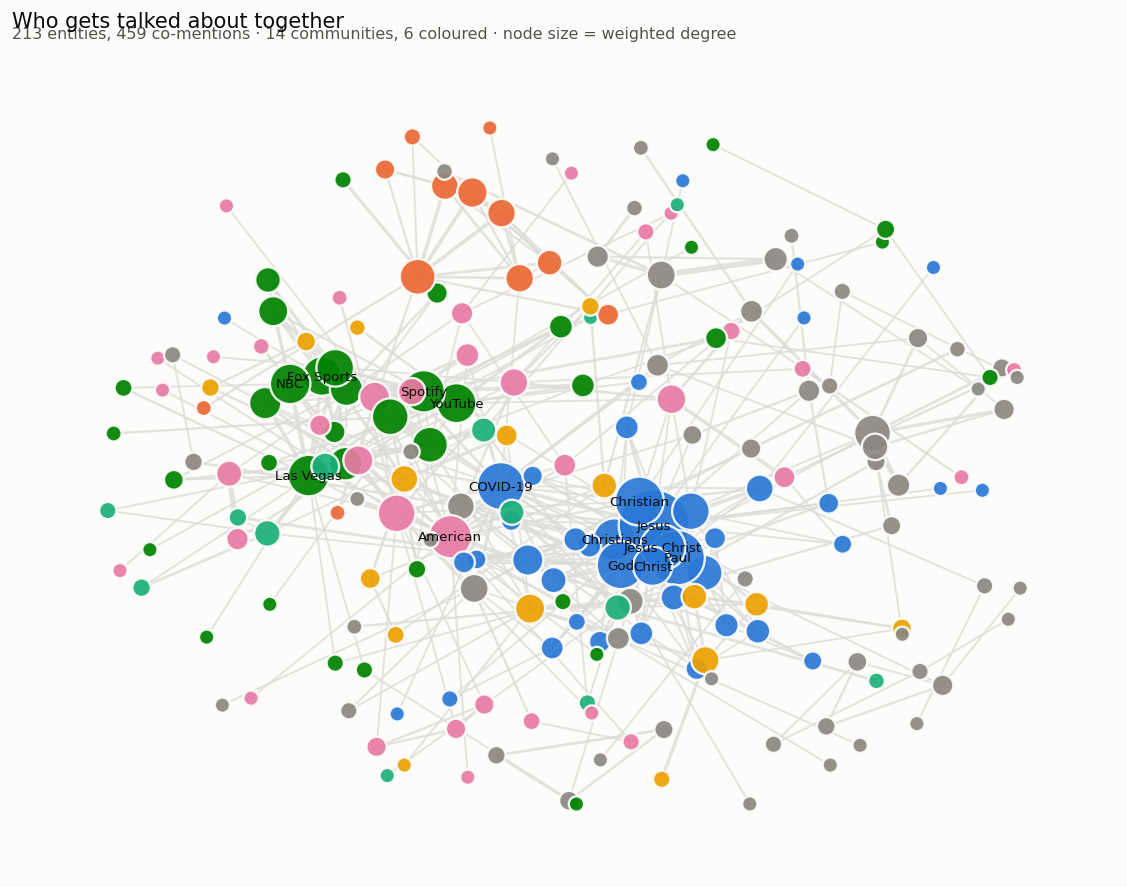

In [9]:
if G.number_of_edges():
    core = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    # Communities give the layout meaning; colour by community, capped at the
    # palette and folded into grey past that.
    communities = nx.community.greedy_modularity_communities(core, weight="weight")
    comm_of = {n: i for i, c in enumerate(communities) for n in c}
    n_shown = min(len(communities), 6)
    node_color = [PALETTE[comm_of[n]] if comm_of[n] < n_shown else INK_MUTED
                  for n in core.nodes()]

    deg = dict(core.degree(weight="weight"))
    pos = nx.spring_layout(core, seed=11, k=0.6, weight="weight")

    fig, ax = plt.subplots(figsize=(9.5, 7.5))
    nx.draw_networkx_edges(core, pos, ax=ax, edge_color="#dedcd7",
                           width=[0.4 + 0.25*core[u][v]["weight"] for u, v in core.edges()],
                           alpha=0.8)
    nx.draw_networkx_nodes(core, pos, ax=ax, node_color=node_color,
                           node_size=[60 + 8*deg[n] for n in core.nodes()],
                           alpha=0.92, edgecolors="#fcfcfb", linewidths=1.4)
    hubs = sorted(deg, key=deg.get, reverse=True)[:14]
    nx.draw_networkx_labels(core, pos, ax=ax, labels={n: n[:22] for n in hubs},
                            font_size=8, font_color=INK)
    ax.axis("off")
    finish(ax, title="Who gets talked about together",
           subtitle=f"{core.number_of_nodes()} entities, {core.number_of_edges()} co-mentions "
                    f"· {len(communities)} communities, {n_shown} coloured · node size = weighted degree")
    plt.show()


## 2.4 Communities

A community here is a set of entities that get discussed together. Label them by
their highest-degree members and see whether they correspond to anything real —
a news story, a sport, an ad network.


In [10]:
if G.number_of_edges():
    for i, c in enumerate(communities[:6]):
        members = sorted(c, key=lambda n: deg.get(n, 0), reverse=True)[:8]
        print(f"community {i+1} ({len(c)} entities)")
        print(f"   {', '.join(members)}\n")


community 1 (42 entities)
   Jesus, Paul, Christian, God, COVID-19, Jesus Christ, Christians, Christ

community 2 (37 entities)
   Spotify, Las Vegas, NBC, YouTube, Fox Sports, CBS, Instagram, Twitter

community 3 (36 entities)
   American, Trump, China, United States, George Floyd, America, Australia, New York

community 4 (16 entities)
   Dan, Brian, Hulk, MCU, Mike, Marvel, Vision, Rocket

community 5 (13 entities)
   ESPN, Canada, Toronto, Canadian, TSN, Leafs, Vancouver, Prince George

community 6 (12 entities)
   Omaha, Gil Cohen, Jeff, Trenton, B2B, Grow Omaha, N.A.I. N.P. Dodge, Todd Lemke



## 2.5 Bridges

The entities worth a second look are often not the most-mentioned but the ones
that *connect* communities — they are where two conversations touch.


In [11]:
if G.number_of_edges() and core.number_of_nodes() > 3:
    import pandas as pd
    btw = nx.betweenness_centrality(core, weight=None)
    out = (pd.DataFrame({"entity": list(core.nodes()),
                         "type": [ent_types.get(n, "?") for n in core.nodes()],
                         "mentions": [ent_counts[n] for n in core.nodes()],
                         "betweenness": [btw[n] for n in core.nodes()]})
             .sort_values("betweenness", ascending=False).head(12))
    print(out.round(3).to_string(index=False))


       entity   type  mentions  betweenness
     COVID-19 PERSON       114        0.345
        Jesus PERSON       341        0.292
     American   NORP        89        0.174
      YouTube    ORG        91        0.169
          Dan PERSON        76        0.166
United States    GPE        56        0.103
    Christian   NORP       105        0.101
         Jeff PERSON        70        0.099
        Trump    ORG       133        0.095
         Paul PERSON       145        0.095
          MCU    ORG        34        0.092
      Twitter PERSON       102        0.086


## 2.6 Caveats

* **NER on ASR output is noisy.** `en_core_web_sm` was trained on edited text.
  Transcripts have no capitalisation cues from the speaker, mis-heard proper
  nouns, and no punctuation the model can trust. Expect junk entities; expect
  real ones to be missed.
* **No entity linking.** "Biden", "Joe Biden" and "the President" are three
  nodes. Any serious count needs entity resolution first.
* **Same turn ≠ related.** A long turn can hold two unrelated names. Tightening
  to a sentence window trades recall for precision; there is no free choice here,
  so state the one you made.
* **Coverage.** Only diarized episodes have turns (~65% in the full corpus), so
  this graph describes a third of the corpus.
* **Two months.** May–June 2020. The entity mix is dominated by that moment and
  generalises to nothing else.
